
MAGIC Gamma Telescope
Raw X shape: (19020, 10)
Raw y classes: ['g', 'h']
   fLength:   fWidth:  fSize:  fConc:  fConc1:    fAsym:  fM3Long:  fM3Trans:  \
0   28.7967   16.0021  2.6449  0.3918   0.1982   27.7004   22.0110    -8.2027   
1   31.6036   11.7235  2.5185  0.5303   0.3773   26.2722   23.8238    -9.9574   
2  162.0520  136.0310  4.0612  0.0374   0.0187  116.7410  -64.8580   -45.2160   
3   23.8172    9.5728  2.3385  0.6147   0.3922   27.2107   -6.4633    -7.1513   
4   75.1362   30.9205  3.1611  0.3168   0.1832   -5.5277   28.5525    21.8393   

   fAlpha:    fDist:  
0  40.0920   81.8828  
1   6.3609  205.2610  
2  76.9600  256.7880  
3  10.4490  116.7370  
4   4.6480  356.4620  

Class mapping:
{'g': 0, 'h': 1}

Train shape: (14265, 10)
Test shape: (4755, 10)

Binarized train shape: (14265, 479)
Binarized test shape: (4755, 479)

First 10 generated feature names:
   fLength: <= 12.303900241851807
   fLength: <= 12.392450332641602
   fLength: <= 12.516000270843506
   fLength:

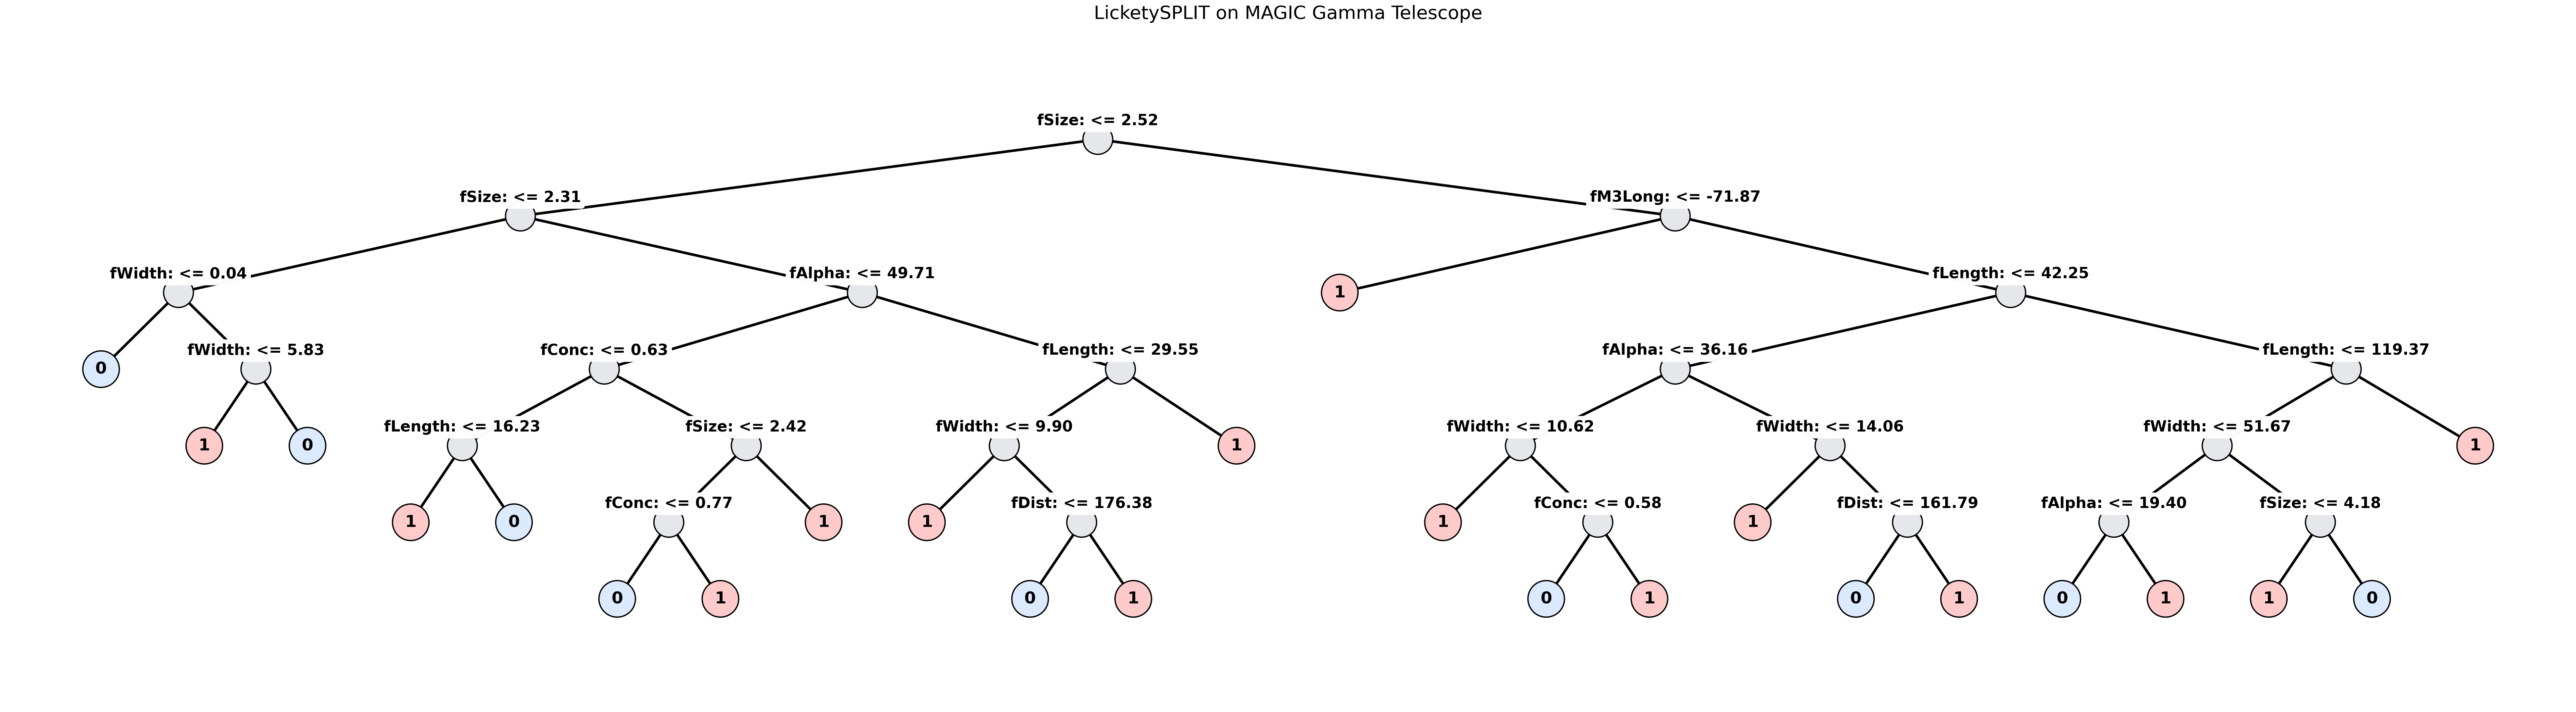


Weighted model objective: 3639.1490000000003
Weighted model test accuracy: 0.8435331230283911

Weighted predict leaves by class:
  class 0 (g): 10
  class 1 (h): 19
Weighted total leaves: 29

Iris
Raw X shape: (150, 4)
Raw y classes: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']
   sepallength  sepalwidth  petallength  petalwidth
0          5.1         3.5          1.4         0.2
1          4.9         3.0          1.4         0.2
2          4.7         3.2          1.3         0.2
3          4.6         3.1          1.5         0.2
4          5.0         3.6          1.4         0.2

Class mapping:
{'Iris-setosa': 0, 'Iris-versicolor': 1, 'Iris-virginica': 2}

Train shape: (112, 4)
Test shape: (38, 4)

Binarized train shape: (112, 38)
Binarized test shape: (38, 38)

First 10 generated feature names:
   sepallength <= 4.700000047683716
   sepallength <= 4.8500001430511475
   sepallength <= 4.950000047683716
   sepallength <= 5.150000095367432
   sepallength <= 5.35000014305114

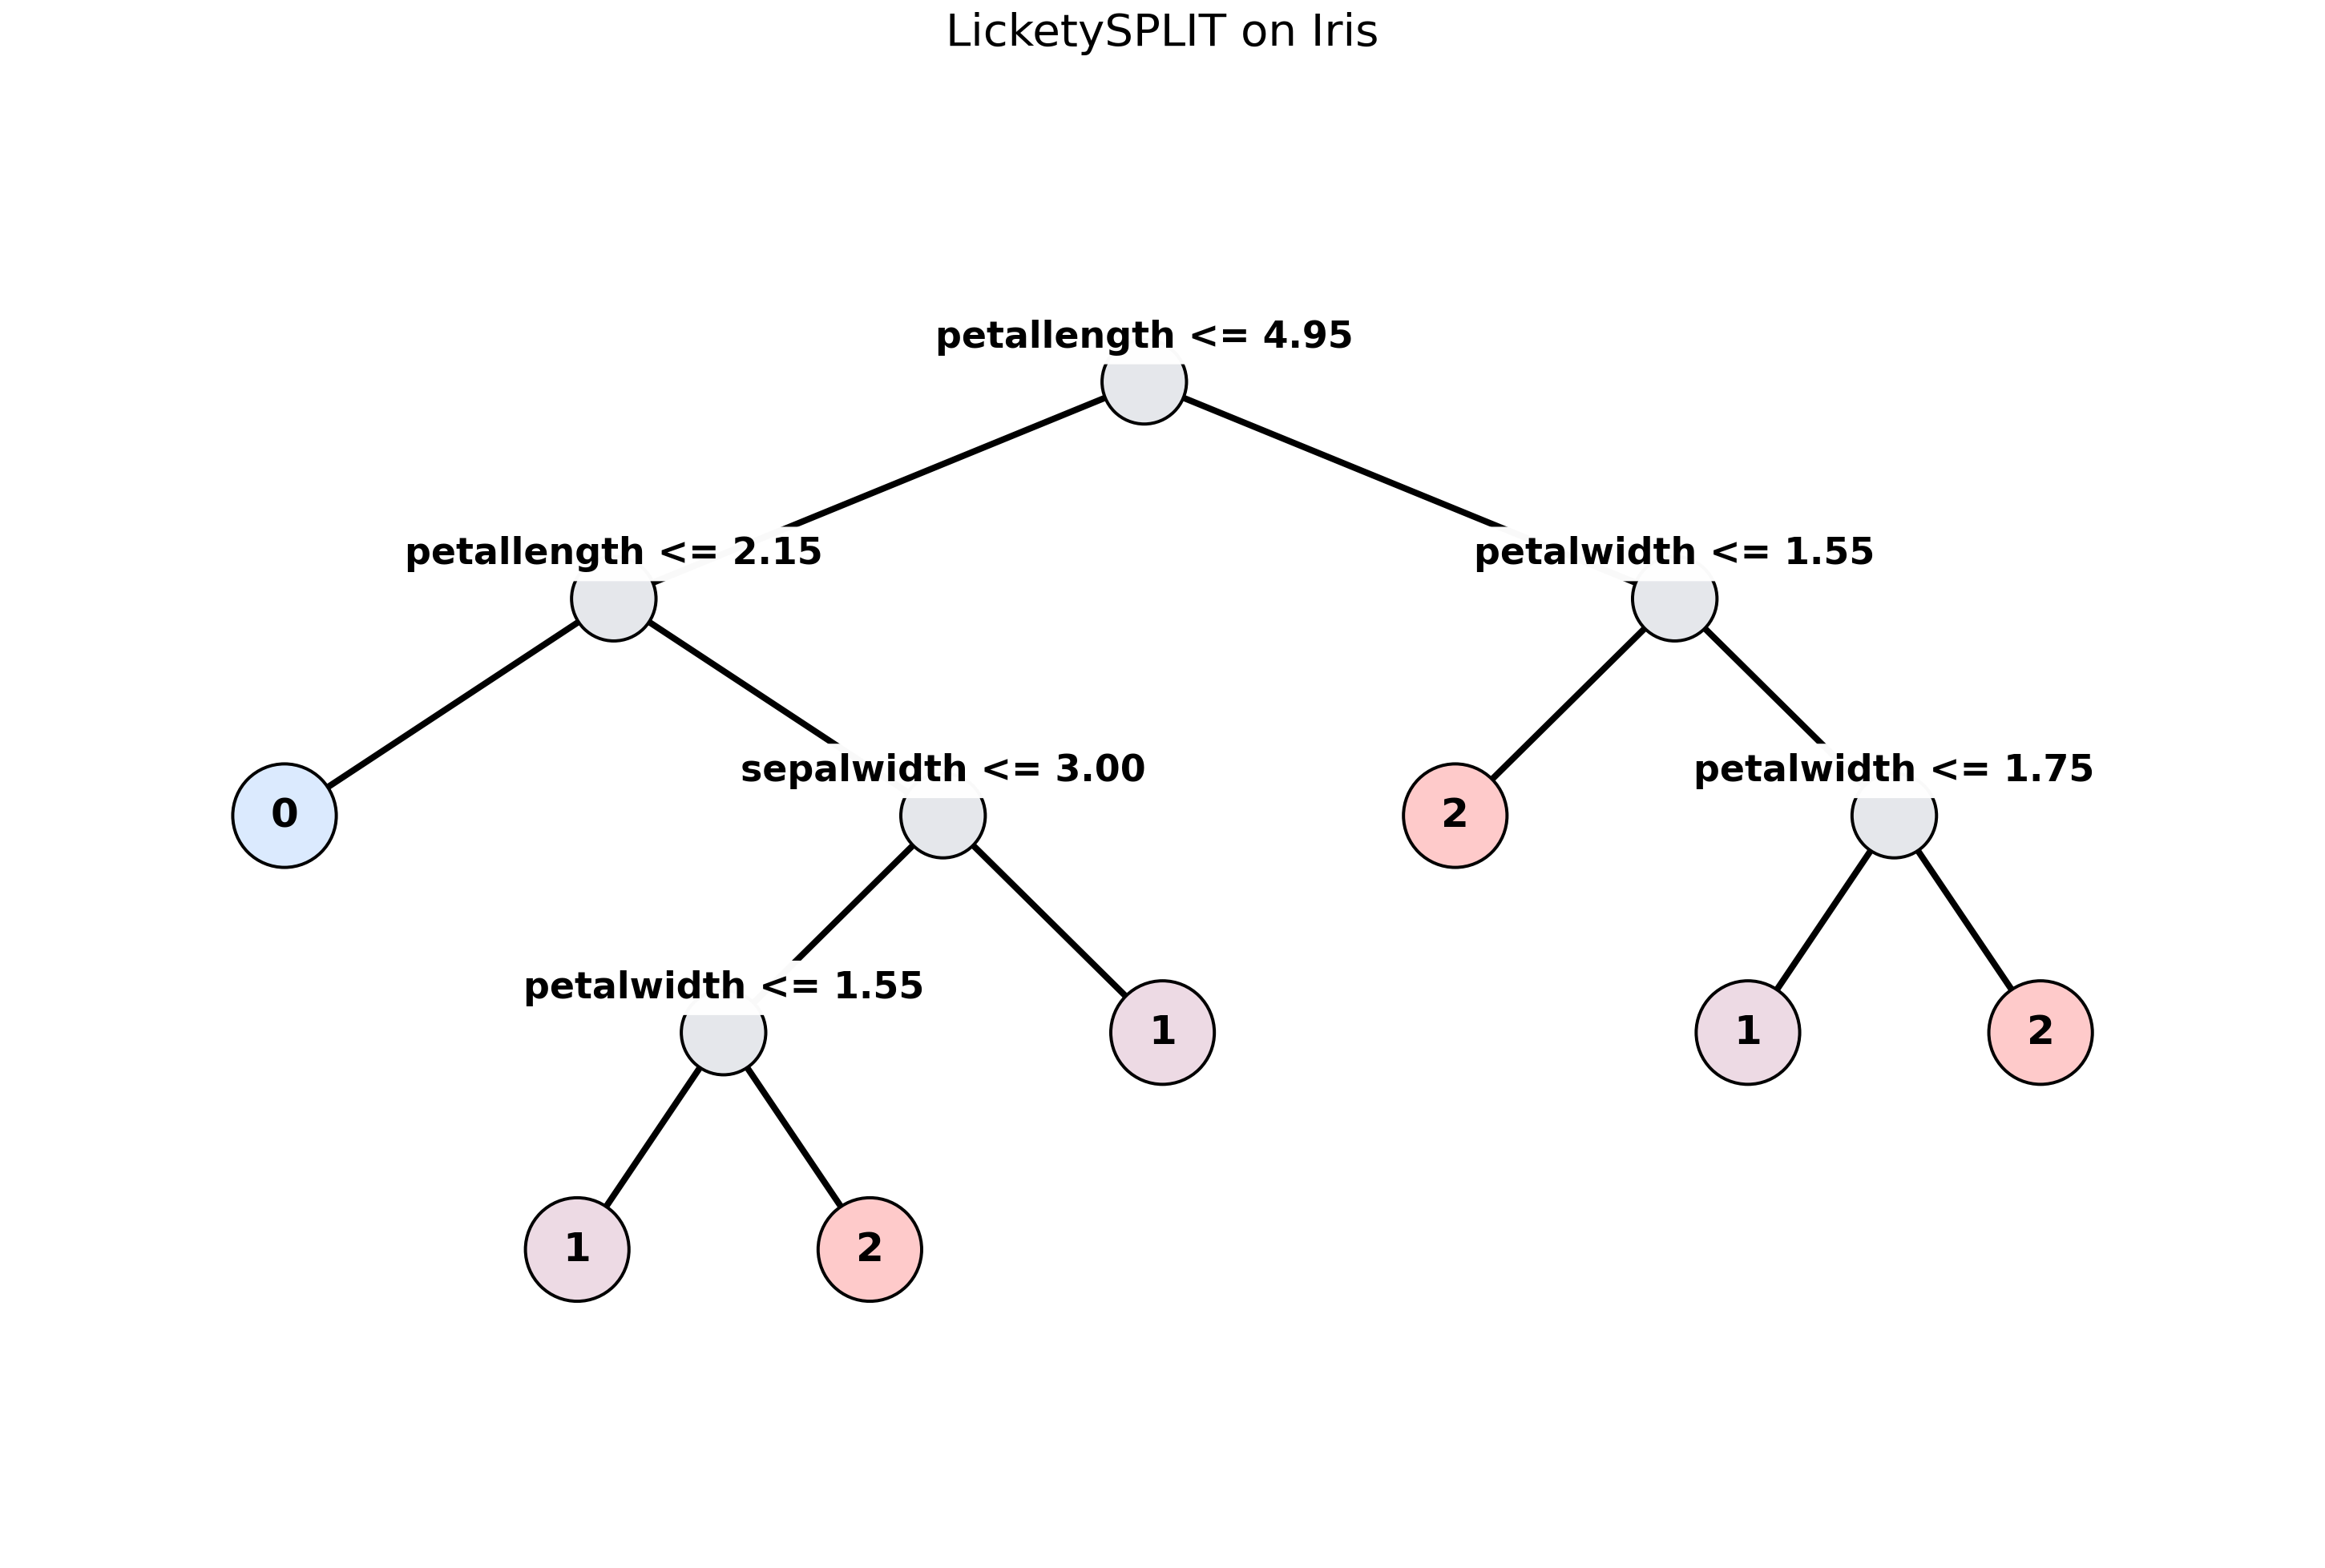


Weighted model objective: 1.043
Weighted model test accuracy: 0.9736842105263158

Weighted predict leaves by class:
  class 0 (Iris-setosa): 1
  class 1 (Iris-versicolor): 3
  class 2 (Iris-virginica): 3
Weighted total leaves: 7


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from licketysplit import LicketySPLIT, ThresholdGuessBinarizer


datasets = [
    {
        "label": "MAGIC Gamma Telescope",
        "openml_name": "MagicTelescope",
        "openml_version": 1,
        "lambda_leaf": 0.001,
        "depth_budget": 6,
        "weighted_depth_budget": 6,
    },
    {
        "label": "Iris",
        "openml_name": "iris",
        "openml_version": 1,
        "lambda_leaf": 0.001,
        "depth_budget": 5,
        "weighted_depth_budget": 5,
    },
]


for cfg in datasets:
    print("\n" + "=" * 90)
    print(cfg["label"])
    print("=" * 90)

    data = fetch_openml(name=cfg["openml_name"], version=cfg["openml_version"], as_frame=True)

    X_raw = data.data
    y_raw = data.target

    print("Raw X shape:", X_raw.shape)
    print("Raw y classes:", sorted(y_raw.unique()))
    print(X_raw.head())

    classes = sorted(y_raw.unique())
    class_to_int = {c: i for i, c in enumerate(classes)}
    int_to_class = {i: c for c, i in class_to_int.items()}

    y = y_raw.map(class_to_int).astype(np.int32).to_numpy()

    print("\nClass mapping:")
    print(class_to_int)

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_raw,
        y,
        test_size=0.25,
        random_state=0,
        stratify=y,
    )

    print("\nTrain shape:", X_train_raw.shape)
    print("Test shape:", X_test_raw.shape)

    binarizer = ThresholdGuessBinarizer(
        learning_rate=0.1,
        n_estimators=100,
        max_depth=3,
        random_state=0,
        column_elimination=False,
    )

    X_train_bin = binarizer.fit_transform(X_train_raw, y_train)
    X_test_bin = binarizer.transform(X_test_raw)

    feature_names = binarizer.get_feature_names_out()

    print("\nBinarized train shape:", X_train_bin.shape)
    print("Binarized test shape:", X_test_bin.shape)

    print("\nFirst 10 generated feature names:")
    for name in feature_names[:10]:
        print("  ", name)

    print("\nThresholds learned:")
    print(len(binarizer.thresholds_))

    fmap = binarizer.feature_map()
    print("\nFeature map:")
    print(fmap)

    model = LicketySPLIT(
        cache_mode="fingerprint", # choose between fingerprint and bitvector if caching is on. bitvector uses more memory but is more reliable.
        cost_caching_enabled=True, # allow caching for speedups at the expense of memory use
    )

    model.fit(
        X_train_bin,
        y_train,
        lambda_leaf=cfg["lambda_leaf"], # regularization parameter: trade-off between putting a leaf and splitting more. penalizes the number of leaves.
        depth_budget=cfg["depth_budget"],
        lookahead_k=1, # how optimal the optimization is. LicketySPLIT is lookahead_k=1, optimal is lookahead_k=depth_budget-1, you can interpolate between the two to choose a speed-optimality trade-off
    )

    print("\nModel fit complete.")
    print("Objective:", model.objective_)

    y_pred_train = model.predict(X_train_bin)
    y_pred_test = model.predict(X_test_bin)

    print("\nTrain accuracy:", accuracy_score(y_train, y_pred_train))
    print("Test accuracy:", accuracy_score(y_test, y_pred_test))

    print("\nConfusion matrix:")
    print(confusion_matrix(y_test, y_pred_test))

    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred_test,
        target_names=[str(int_to_class[i]) for i in range(len(int_to_class))]
    ))

    leaf_counts = model.leaf_counts()

    print("\nPredict leaves by class:")
    for c, count in enumerate(leaf_counts["predict_by_class"]):
        print(f"  class {c} ({int_to_class[c]}): {count}")

    print("Total leaves:", leaf_counts["total"])

    train_split_counts = model.split_counts(X_train_bin)
    test_split_counts = model.split_counts(X_test_bin)

    print("\nSplit counts on train:")
    print(pd.Series(train_split_counts).describe())

    print("\nSplit counts on test:")
    print(pd.Series(test_split_counts).describe())

    paths = model.leaf_paths()

    print("""
    Path encoding:
    +j means branch on feature index j-1 going left / true
    -j means branch on feature index j-1 going right / false
    """)

    paths2, actions2 = model.get_tree_paths()

    print("\nLeaf paths and actions:")
    for i, (path, action) in enumerate(zip(paths2, actions2)):
        readable = int_to_class.get(int(action), action)
        print(f"Leaf {i}: path={path}, action={action} ({readable})")

    feature_names_rounded = [
        name.rsplit(" <= ", 1)[0] + " <= " + f"{float(name.rsplit(' <= ', 1)[1]):.2f}"
        if " <= " in name else name
        for name in feature_names
    ]

    model.plot_tree(
        feature_names=feature_names_rounded,
        figsize=(30, 16),
        title=f"LicketySPLIT on {cfg['label']}",
        show=True,
    )

    sample_weights = np.ones_like(y_train, dtype=np.float64)

    if len(classes) > 1:
        sample_weights[y_train == 1] = 2.0

    model_weighted = LicketySPLIT(
        cache_mode="fingerprint",
        cost_caching_enabled=True,
    )

    model_weighted.fit(
        X_train_bin,
        y_train,
        lambda_leaf=cfg["lambda_leaf"],
        depth_budget=cfg["weighted_depth_budget"],
        lookahead_k=1,
        sample_weights=sample_weights, # you can also pass sample weights
    )

    y_pred_weighted = model_weighted.predict(X_test_bin)

    print("\nWeighted model objective:", model_weighted.last_objective)
    print("Weighted model test accuracy:", accuracy_score(y_test, y_pred_weighted))

    weighted_leaf_counts = model_weighted.leaf_counts()

    print("\nWeighted predict leaves by class:")
    for c, count in enumerate(weighted_leaf_counts["predict_by_class"]):
        print(f"  class {c} ({int_to_class[c]}): {count}")

    print("Weighted total leaves:", weighted_leaf_counts["total"])